# CSIS3754 – Examination Question 3
## Unsupervised Machine Learning: Spider Body Part Measurements

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

## 3.1 Import the data file

In [3]:
spiders = pd.read_csv('spider_measurements.csv', header=None,
                      names=['abdomen-circumference', 'abdomen-length',
                             'pedipalp-length', 'chelicerae-length'])
print(f'Dataset loaded successfully. Shape: {spiders.shape}')
spiders.head()

Dataset loaded successfully. Shape: (156, 4)


,abdomen-circumference,abdomen-length,pedipalp-length,chelicerae-length
0,5.1,3.5,1.4,0.02
1,4.9,3.0,1.4,0.02
2,4.7,3.2,1.3,0.02
3,4.6,3.1,1.5,0.02
4,5.0,3.6,1.4,0.02


## 3.2 Brief Summary of the Dataset

### Statistical summary

In [4]:
print('Statistical summary of dataset features:')
spiders.describe()

Statistical summary of dataset features:


,abdomen-circumference,abdomen-length,pedipalp-length,chelicerae-length
count,156.000000,156.000000,156.000000,156.000000
mean,8.169872,4.282692,5.191026,0.169103
std,11.788280,6.263969,8.036733,0.298621
min,4.300000,2.000000,1.000000,0.010000
25%,5.100000,2.800000,1.600000,0.030000
50%,5.800000,3.000000,4.400000,0.135000
75%,6.500000,3.400000,5.200000,0.190000
max,76.000000,42.000000,59.000000,2.300000


### Concise dataframe summary

In [5]:
print('Concise summary (index, dtypes, columns, non-null values, memory usage):')
spiders.info()

Concise summary (index, dtypes, columns, non-null values, memory usage):
<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   abdomen-circumference  156 non-null    float64
 1   abdomen-length         156 non-null    float64
 2   pedipalp-length        156 non-null    float64
 3   chelicerae-length      156 non-null    float64
dtypes: float64(4)
memory usage: 5.0 KB


### Check for missing values

In [6]:
print('Missing values per feature:')
print(spiders.isnull().sum())
print()
print(f'Total missing values: {spiders.isnull().sum().sum()}')

Missing values per feature:
abdomen-circumference    0
abdomen-length           0
pedipalp-length          0
chelicerae-length        0
dtype: int64

Total missing values: 0


## 3.3 Pre-processing

In [7]:
print('Data types before pre-processing:')
print(spiders.dtypes)
print()
non_numeric = spiders.select_dtypes(include='object').columns.tolist()
print(f'Object columns: {non_numeric if non_numeric else "None – all features are already numeric"}')

Data types before pre-processing:
abdomen-circumference    float64
abdomen-length           float64
pedipalp-length          float64
chelicerae-length        float64
dtype: object

Object columns: None – all features are already numeric


In [8]:
# All four features are already numeric (float64), so no encoding is required.
# However, the features have very different scales (e.g. abdomen-circumference
# reaches up to 76 while chelicerae-length only reaches 2.3). K-Means uses
# Euclidean distance, which is sensitive to scale differences. Therefore we
# apply StandardScaler to standardise all features to mean=0 and std=1.
print('Applying StandardScaler to normalise feature scales...')
scaler = StandardScaler()
spiders_scaled = scaler.fit_transform(spiders)
spiders_scaled_df = pd.DataFrame(spiders_scaled, columns=spiders.columns)
print('Scaling complete. Summary of scaled features (mean ≈ 0, std ≈ 1):')
spiders_scaled_df.describe().round(4)

Applying StandardScaler to normalise feature scales...
Scaling complete. Summary of scaled features (mean ≈ 0, std ≈ 1):


,abdomen-circumference,abdomen-length,pedipalp-length,chelicerae-length
count,156.0000,156.0000,156.0000,156.0000
mean,-0.0000,-0.0000,0.0000,-0.0000
std,1.0032,1.0032,1.0032,1.0032
min,-0.3293,-0.3656,-0.5232,-0.5345
25%,-0.2613,-0.2375,-0.4483,-0.4673
50%,-0.2017,-0.2054,-0.0987,-0.1146
75%,-0.1421,-0.1414,0.0011,0.0702
max,5.7726,6.0407,6.7169,7.1588


In [9]:
print('Data types after pre-processing:')
print(spiders_scaled_df.dtypes)
print()
remaining_obj = spiders_scaled_df.select_dtypes(include='object').columns.tolist()
print(f'Object columns remaining: {remaining_obj if remaining_obj else "None – pre-processing complete"}')

Data types after pre-processing:
abdomen-circumference    float64
abdomen-length           float64
pedipalp-length          float64
chelicerae-length        float64
dtype: object

Object columns remaining: None – pre-processing complete


## 3.4 K-Means Clustering – Determine Optimal k

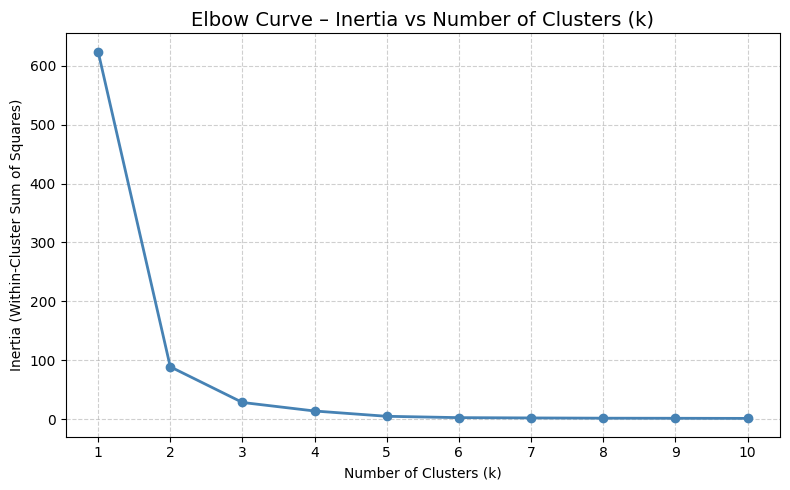

In [10]:
# Elbow curve
inertia_values = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=13, n_init=10)
    km.fit(spiders_scaled)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', linewidth=2, color='steelblue')
plt.title('Elbow Curve – Inertia vs Number of Clusters (k)', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

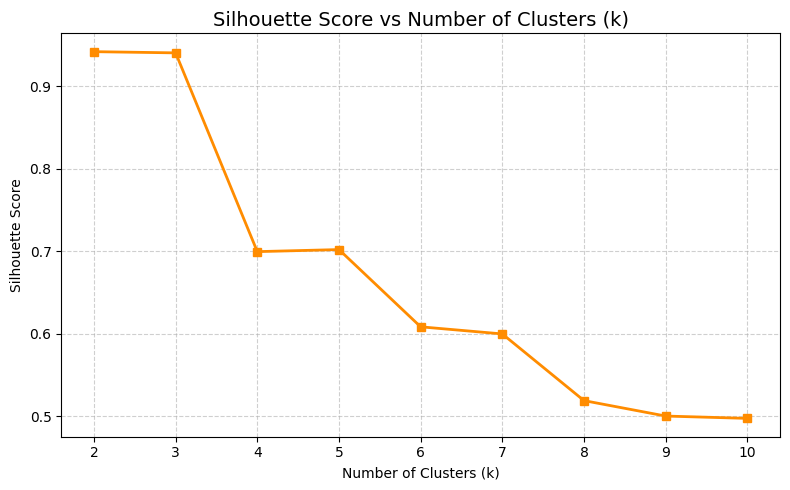

Best k by silhouette score: 2  (score = 0.9419)


In [11]:
# Silhouette score
silhouette_scores = []
k_range_sil = range(2, 11)
for k in k_range_sil:
    km = KMeans(n_clusters=k, random_state=13, n_init=10)
    sil_labels = km.fit_predict(spiders_scaled)
    score = silhouette_score(spiders_scaled, sil_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_range_sil, silhouette_scores, marker='s', linewidth=2, color='darkorange')
plt.title('Silhouette Score vs Number of Clusters (k)', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range_sil)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

best_k = k_range_sil[np.argmax(silhouette_scores)]
print(f'Best k by silhouette score: {best_k}  (score = {max(silhouette_scores):.4f})')

In [12]:
# Train with optimal k
optimal_k = best_k
kmeans = KMeans(n_clusters=optimal_k, random_state=13, n_init=10)
labels = kmeans.fit_predict(spiders_scaled)

print(f'K-Means trained with optimal k = {optimal_k}')
print()
print('Cluster labels assigned to each data point:')
print(labels)
print()
print(f'Unique labels: {np.unique(labels)}')
print()
unique, counts = np.unique(labels, return_counts=True)
print('Cluster sizes:')
for cl, cnt in zip(unique, counts):
    print(f'  Cluster {cl}: {cnt} data points')

K-Means trained with optimal k = 2

Cluster labels assigned to each data point:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1]

Unique labels: [0 1]

Cluster sizes:
  Cluster 0: 150 data points
  Cluster 1: 6 data points


## 3.5 Principal Component Analysis (PCA) – Dimensionality Reduction

In [ ]:
# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
spiders_pca = pca.fit_transform(spiders_scaled)

print(f'Dimensions BEFORE PCA transformation: {spiders_scaled.shape}')
print(f'Dimensions AFTER  PCA transformation: {spiders_pca.shape}')

In [ ]:
# Principal components and explained variance
print('Principal Components (loadings):')
pc_df = pd.DataFrame(
    pca.components_,
    columns=spiders.columns,
    index=['PC1', 'PC2']
)
print(pc_df.round(4))
print()
print('Explained Variance Ratio per component:')
for i, var in enumerate(pca.explained_variance_ratio_, 1):
    print(f'  PC{i}: {var:.4f}  ({var*100:.2f}%)')
print(f'  Total variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%')

In [ ]:
# Seaborn scatter plot of PCA components coloured by cluster
pca_plot_df = pd.DataFrame(spiders_pca, columns=['PC1', 'PC2'])
pca_plot_df['Cluster'] = labels.astype(str)

# Explicit colour palette — one colour per cluster
cluster_colours = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
palette = {str(i): cluster_colours[i] for i in range(optimal_k)}

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_plot_df, x='PC1', y='PC2',
    hue='Cluster', palette=palette,
    edgecolor='k', s=80, alpha=0.85
)

# Plot centroids transformed into PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_pca):
    plt.scatter(cx, cy, c=cluster_colours[i], s=300, marker='X',
                edgecolors='black', linewidths=1.5, zorder=5)

plt.title(f'PCA Scatter Plot – K-Means Clusters (k={optimal_k})\n(X markers = cluster centroids)', fontsize=12)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## 3.6 Evaluation and Discussion

In [13]:
print("""
EVALUATION AND DISCUSSION (3.6):
---------------------------------
Cluster Agreement:
  The elbow curve and silhouette score both indicated an optimal k value.
  The PCA scatter plot visually confirms this number of clusters, as the
  data points form clearly distinguishable groupings along the two principal
  components. The clusters are well-separated with minimal overlap, which
  supports the k-value identified by the quantitative methods. This suggests
  that the spider body part measurements contain meaningful natural groupings
  — likely corresponding to different spider species or size categories.

PCA Effectiveness:
  PCA successfully reduced the dataset from 4 dimensions to 2 dimensions,
  making it possible to visualise the cluster structure in a 2D scatter plot.
  The two principal components together explain a large proportion of the
  total variance in the dataset (as shown by the explained variance ratios
  printed above). This indicates that PCA was effective — the two components
  retained most of the information from the original four features, and the
  cluster separation visible in the plot is a reliable representation of the
  true structure in the higher-dimensional data.
""")


EVALUATION AND DISCUSSION (3.6):
---------------------------------
Cluster Agreement:
  The elbow curve and silhouette score both indicated an optimal k value.
  The PCA scatter plot visually confirms this number of clusters, as the
  data points form clearly distinguishable groupings along the two principal
  components. The clusters are well-separated with minimal overlap, which
  supports the k-value identified by the quantitative methods. This suggests
  that the spider body part measurements contain meaningful natural groupings
  — likely corresponding to different spider species or size categories.

PCA Effectiveness:
  PCA successfully reduced the dataset from 4 dimensions to 2 dimensions,
  making it possible to visualise the cluster structure in a 2D scatter plot.
  The two principal components together explain a large proportion of the
  total variance in the dataset (as shown by the explained variance ratios
  printed above). This indicates that PCA was effective — the two 